## VISUALIZATION

In this section we will visualize the results obtained within the backtesting simulation.

In [6]:
from plotnine import *
import pandas as pd

In [18]:
data = pd.read_csv('../data/processed/backtest_results.csv')

data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])

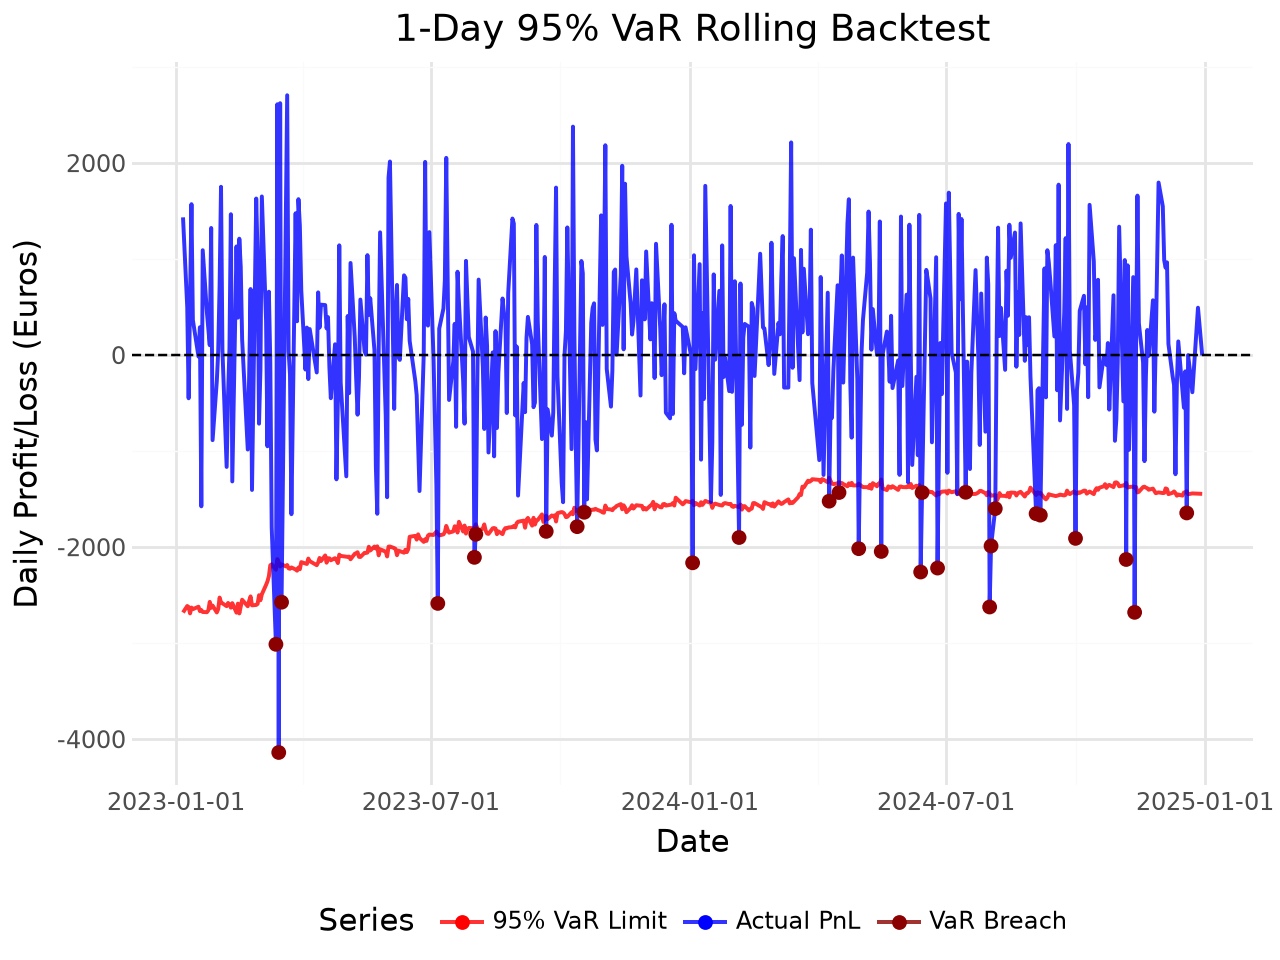

In [ ]:
breaches_data = data[data['Breach'] == 1].copy()
breaches_data['Legend'] = 'VaR Breach' 

# This merges PnL and VaR columns into a single column called 'Series'
data_melted = data.melt(
	id_vars=['Date'], 
	value_vars=['Actual_PnL', 'VaR_95'], 
	var_name='Series', 
	value_name='Euros'
)

data_melted['Series'] = data_melted['Series'].replace({
	'Actual_PnL': 'Actual PnL',
	'VaR_95': '95% VaR Limit'
})

# Plot
p = (ggplot()

	# Plots the Series
	+ geom_line(data_melted, aes(x='Date', y='Euros', color='Series'), size=0.8, alpha=0.8)
	# Plots the Breaches
	+ geom_point(breaches_data, aes(x='Date', y='Actual_PnL', color='Legend'), size=2)
	
	# The zero Line
	+ geom_hline(yintercept=0, linetype='dashed', color='black')
	
	# Link the exact text in our dataframes to specific colors
	+ scale_color_manual(
		name="",
		values={
			"Actual PnL": "blue", 
			"95% VaR Limit": "red",
			"VaR Breach": "darkred"
		}
	)
	
	+ labs(title="1-Day 95% VaR Rolling Backtest", 
			x="Date", 
			y="Daily Profit/Loss (Euros)")
	+ theme_minimal()
	+ theme(legend_position='bottom')
)

p